Scenario Analysis Performance Assessment- 05/05/2026 - edwgol5635

In [1]:
categorical_cols=['Ship Mode','Segment','Country/Reigon','Category','Sub-Category']

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Loan principal
P = 300000

# Scenario definitions
scenarios = {
    "Scenario 1 (3%, 15 years)": {"rate": 0.03, "years": 15},
    "Scenario 2 (5%, 30 years)": {"rate": 0.05, "years": 30},
    "Scenario 3 (8%, 40 years)": {"rate": 0.08, "years": 40}
}

# Loan amortization function
def monthly_payment(P, annual_rate, years):
    r = annual_rate / 12
    n = years * 12
    return P * r * (1 + r)**n / ((1 + r)**n - 1)

# Calculate total repayments
results = []

for name, params in scenarios.items():
    M = monthly_payment(P, params["rate"], params["years"])
    total_payment = M * params["years"] * 12
    results.append([name, round(M, 2), round(total_payment, 2)])

results_df = pd.DataFrame(
    results,
    columns=["Scenario", "Monthly Payment ($)", "Total Repayment ($)"]
)

results_df


,Scenario,Monthly Payment ($),Total Repayment ($)
0,"Scenario 1 (3%, 15 years)",2071.74,372914.09
1,"Scenario 2 (5%, 30 years)",1610.46,579767.35
2,"Scenario 3 (8%, 40 years)",2085.94,1001248.83


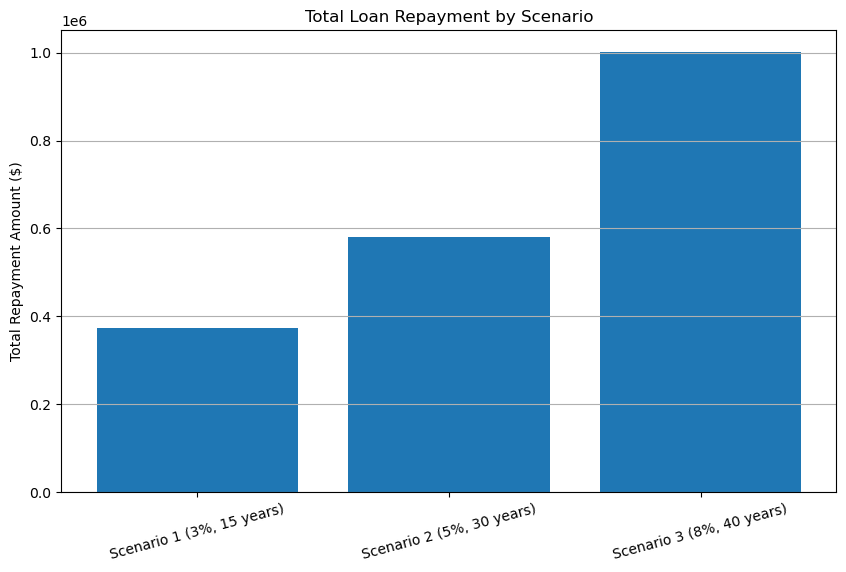

In [3]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Scenario"], results_df["Total Repayment ($)"])
plt.title("Total Loan Repayment by Scenario")
plt.ylabel("Total Repayment Amount ($)")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

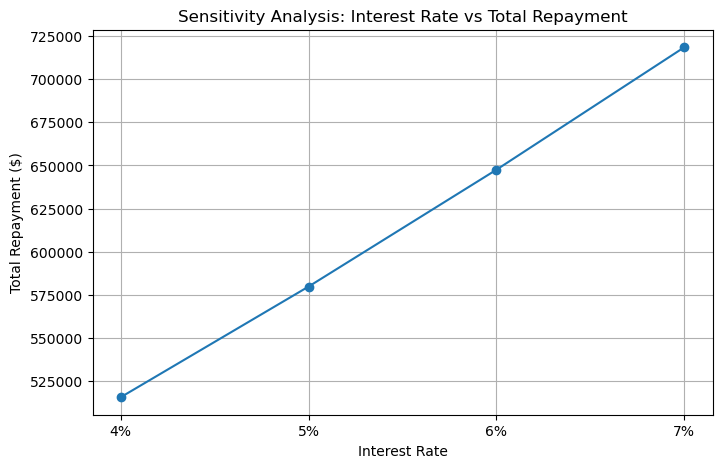

,Interest Rate,Total Repayment ($)
0,4%,515608.52
1,5%,579767.35
2,6%,647514.57
3,7%,718526.69


In [4]:
sensitivity_rates = [0.04, 0.05, 0.06, 0.07]
sensitivity_results = []

for rate in sensitivity_rates:
    M = monthly_payment(P, rate, 30)
    total_payment = M * 30 * 12
    sensitivity_results.append([f"{int(rate*100)}%", round(total_payment, 2)])

sensitivity_df = pd.DataFrame(
    sensitivity_results,
    columns=["Interest Rate", "Total Repayment ($)"]
)

plt.figure(figsize=(8, 5))
plt.plot(
    sensitivity_df["Interest Rate"],
    sensitivity_df["Total Repayment ($)"],
    marker="o"
)
plt.title("Sensitivity Analysis: Interest Rate vs Total Repayment")
plt.xlabel("Interest Rate")
plt.ylabel("Total Repayment ($)")
plt.grid(True)
plt.show()

sensitivity_df